In [ ]:
# Plot ROC curve with various thresholds for single experiment

import json

K = 10
n = 1000
label_frequency = 0.5
train_pi = 0.2
test_pi = 0.8
exp_number = 2

file_path = f"output/GaussTest/{n}/0.5/{train_pi}/{test_pi}/nnPUcc/{label_frequency}/{exp_number}/metrics.json"

with open(file_path, "r") as f:
    metrics_contents = json.load(f)

model = 'drpu'
pi_estimates = metrics_contents['test_pis']
roc_data = metrics_contents['TC'][model]['roc_curve']
fpr = roc_data['fpr']
tpr = roc_data['tpr']
thresholds = roc_data['thresholds']
thresholds = [float(threshold) for threshold in thresholds]

# roc curve
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')

# threshold = 0.5
idx_05 = np.argmin(np.abs([threshold - 0.5 for threshold in thresholds]))
plt.scatter(fpr[idx_05], tpr[idx_05], color='orange', label='Threshold = 0.5', s=80, zorder=5, marker='*')

# optimal threshold 
optimal_threshold = train_pi * (1 - test_pi) / ((1 - train_pi) * test_pi + train_pi * (1 - test_pi))
idx_optimal = np.argmin(np.abs([threshold - optimal_threshold for threshold in thresholds]))
plt.scatter(fpr[idx_optimal], tpr[idx_optimal], color='red', label=f'Optimal Threshold = {optimal_threshold:.2f}', s=80, zorder=5, marker='^')

# heuristic thresholds - Youden’s J Statistic
J = [tpr[i] - fpr[i] for i in range(len(fpr))]
idx_youden = np.argmax(J)
youden_threshold = thresholds[idx_youden]
plt.scatter(fpr[idx_youden], tpr[idx_youden], color='blue', label=f'Youden’s J Statistic = {youden_threshold:.2f}', s=80, zorder=5, marker='^')

for pi_method in ["DR", "KM1", "KM2"]:
    pi = metrics_contents['test_pis'][pi_method]
    corrected_threshold = train_pi * (1 - pi) / ((1 - train_pi) * pi + train_pi * (1 - pi))
    idx_corr = np.argmin(np.abs([threshold - corrected_threshold for threshold in thresholds]))
    plt.scatter(fpr[idx_corr], tpr[idx_corr], color='green', label=f"{pi_method} Threshold = {corrected_threshold:.2f} ($\hat\pi'={pi:.2}$)", s=80, zorder=5, marker='x', linewidths=2)
    plt.annotate(f'{pi_method}', 
                 (fpr[idx_corr], tpr[idx_corr]), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontsize=10, 
                 color='green')

plt.title(f"ROC Curve for {model} ($\pi={train_pi}, \pi'={test_pi}$)")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Experiment to test MLLS EM estimation of test priors using Ringnorm dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torchhd.datasets import Ringnorm
import random

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Parameters
train_size_per_class = 500
test_size = 1000
input_dim = 20
hidden_dim = 10
num_epochs = 100
learning_rate = 0.01
test_priors = [0.1 * i for i in range(1, 10)]  # [0.1, 0.2, ..., 0.9]
n_repeats = 10
max_em_iter = 5
tol = 1e-3

# Define simple MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        return torch.sigmoid(self.fc2(x)).view(-1)

# MLLS EM estimation
def run_em(probs, train_pi, max_iter=20, tol=1e-3):
    new_pi = train_pi
    for i in range(max_iter):
        nom = (new_pi / train_pi) * probs
        denom = nom + ((1 - new_pi) / (1 - train_pi)) * (1 - probs)
        adjusted_post = nom / denom
        updated_pi = adjusted_post.mean().item()
        if abs(updated_pi - new_pi) < tol:
            break
        new_pi = updated_pi
    print(f"EM converged in {i+1} iterations, estimated π': {new_pi}")
    return new_pi

# Storage
results = {p: [] for p in test_priors}

# Main experiment
for _ in range(n_repeats):
    # Prepare training data with balanced priors (0.5 / 0.5)
    full_data = Ringnorm(root='./data', train=True, download=True)
    x_train = []
    y_train = []
    x_test, y_test = [], []
    pos_count, neg_count = 0, 0
    for x, y in full_data:
        if y == 1:
            if pos_count < train_size_per_class:
                x_train.append(x)
                y_train.append(1)
                pos_count += 1
            else:
                x_test.append(x)
                y_test.append(1)
        elif y == 0:
            if neg_count < train_size_per_class:
                x_train.append(x)
                y_train.append(0)
                neg_count += 1
            else:
                x_test.append(x)
                y_test.append(0)


    x_train = torch.stack(x_train)
    y_train = torch.tensor(y_train)

    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    # Train model
    model = MLP(input_dim=input_dim, hidden_dim=hidden_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        for xb, yb in train_loader:
            pred = model(xb)
            loss = F.binary_cross_entropy(pred, yb.float())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Run test sets for various priors
    full_test_data = list(zip(x_test, y_test))
    for pi_test in test_priors:
        print(f'\nTest prior π\'={pi_test}')
        n_pos = int(test_size * pi_test)
        n_neg = test_size - n_pos
        print(f'Sampling {n_pos} positive and {n_neg} negative instances.')
        pos_samples = [x for x, y in full_test_data if y == 1][:n_pos]
        neg_samples = [x for x, y in full_test_data if y == 0][:n_neg]
        x_test_sel = torch.stack(pos_samples + neg_samples)
        print(f'selected test set size: {x_test_sel.shape[0]}')
        print(f'selected data: {x_test_sel}')
        # y_test_sel = torch.tensor([1]*n_pos + [0]*n_neg)

        with torch.no_grad():
            probs = model(x_test_sel).cpu()
            print(probs)

        estimated_pi = run_em(probs, train_pi=0.5, max_iter=max_em_iter, tol=tol)
        print(estimated_pi)
        results[pi_test].append(estimated_pi)

import pandas as pd

# Summarize results
summary = {
    "True π'": [],
    "Estimated π' (mean)": [],
    "Estimated π' (std)": [],
}

for pi_test, estimates in results.items():
    summary["True π'"].append(round(pi_test, 2))
    summary["Estimated π' (mean)"].append(round(np.mean(estimates), 4))
    summary["Estimated π' (std)"].append(round(np.std(estimates), 4))

df_results = pd.DataFrame(summary)
df_results


## Experiment 1 - Synthethic (Gauss)

In [ ]:
# gauss - test
from PULS.models import LabelShiftConfig
from PULS.dataset import Gauss_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_config import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss, nnPUccLoss_CE

K = 10
n = 5000
label_frequency = 0.5
dataset_name = "Gauss-testrep"

for train_pi in [0.2, 0.4, 0.6, 0.8]:
    for test_pi in [0.2, 0.4, 0.6, 0.8]:
        for exp_number in range(K):

            label_shift_config = LabelShiftConfig(train_prior=train_pi, train_n_samples=n, test_prior=test_pi, test_n_samples=n)

            dataset_config = DatasetConfig(
                f"{dataset_name}/{label_shift_config.train_n_samples or 'all'}/0.8/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
                DatasetClass=Gauss_PULS,
                PULabelerClass=SCAR_CC_Labeler,
            )
            
            gauss_experiment_config = ExperimentConfig(
                PULoss=nnPUccLoss,  # sigmoid loss
                dataset_config=dataset_config,
                label_frequency=label_frequency,
                exp_number=exp_number,
                force_cpu=True, 
            )

            experiment = PULSExperiment(experiment_config=gauss_experiment_config, label_shift_config=label_shift_config)
            # experiment.train_nnpu_km2_and_test()
            experiment.train_all()
            experiment.test_shifted(plot_model_outputs=exp_number==0)

            # print(experiment.metrics)
            # print(experiment.test_pis)

            # Test nnPU with CE loss
            label_shift_config = LabelShiftConfig(train_prior=train_pi, train_n_samples=n, test_prior=test_pi, test_n_samples=n)

            dataset_config = DatasetConfig(
                f"{dataset_name}-CE/{label_shift_config.train_n_samples or 'all'}/0.8/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
                DatasetClass=Gauss_PULS,
                PULabelerClass=SCAR_CC_Labeler,
            )
            
            gauss_experiment_config = ExperimentConfig(
                PULoss=nnPUccLoss_CE,  # cross-entropy loss instead of sigmoid
                dataset_config=dataset_config,
                label_frequency=label_frequency,
                exp_number=exp_number,
                force_cpu=True,
            )

            experiment = PULSExperiment(experiment_config=gauss_experiment_config, label_shift_config=label_shift_config)
            # experiment.train_nnpu_km2_and_test()
            experiment.train_all()
            experiment.test_shifted(plot_model_outputs=exp_number==0)

            # print(experiment.metrics)
            # print(experiment.test_pis)

[Experiment] PyTorch version: 2.0.1+cpu
[Experiment] CUDA available: False
[Experiment] Using device: cpu
Epoch: 1/50
[nnPU] Model device: cpu
[nnPU] Data tensor device: cpu
[nnPU] Label tensor device: cpu
11/11 [========] - 0s 19ms/step - loss: 0.5159 - acc: 0.5012 - test_loss: 0.3494 - test_accuracy: 64.9200 - pos_fraction: 0.5428
Epoch: 2/50
11/11 [========] - 0s 20ms/step - loss: 0.4944 - acc: 0.5793 - test_loss: 0.3519 - test_accuracy: 67.2400 - pos_fraction: 0.6536
Epoch: 3/50
11/11 [========] - 0s 20ms/step - loss: 0.4737 - acc: 0.6418 - test_loss: 0.3516 - test_accuracy: 69.8800 - pos_fraction: 0.6528
Epoch: 4/50
11/11 [========] - 0s 19ms/step - loss: 0.4541 - acc: 0.6948 - test_loss: 0.3474 - test_accuracy: 72.6000 - pos_fraction: 0.6344
Epoch: 5/50
11/11 [========] - 0s 18ms/step - loss: 0.4350 - acc: 0.7298 - test_loss: 0.3407 - test_accuracy: 74.7400 - pos_fraction: 0.6178
Epoch: 6/50
11/11 [========] - 0s 21ms/step - loss: 0.4166 - acc: 0.7589 - test_loss: 0.3338 - test_a

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


DRPU Threshold: 0.01, Accuracy: 0.8308
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1687 - accuracy: 83.3400 - pos_fraction: 0.5270DRPU Threshold: 0.02, Accuracy: 0.8334
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1687 - accuracy: 83.7800 - pos_fraction: 0.5206DRPU Threshold: 0.03, Accuracy: 0.8378
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1687 - accuracy: 84.1800 - pos_fraction: 0.5154DRPU Threshold: 0.04, Accuracy: 0.8418
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1687 - accuracy: 84.7000 - pos_fraction: 0.5086DRPU Threshold: 0.05, Accuracy: 0.8470
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1687 - accuracy: 84.9400 - pos_fraction: 0.5022DRPU Threshold: 0.06, Accuracy: 0.8494
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1687 - accuracy: 85.1400 - pos_fraction: 0.4974DRPU Threshold: 0.07, Accuracy: 0.8514
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1687 - accuracy: 85.6000 - pos_fraction: 0.4916DRPU Threshold: 0.08, Accur

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 4s - test_loss: 0.1687 - accuracy: 83.0800 - pos_fraction: 0.5316DRPU Threshold: 0.01, Accuracy: 0.8308
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1687 - accuracy: 83.3400 - pos_fraction: 0.5270DRPU Threshold: 0.02, Accuracy: 0.8334
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1687 - accuracy: 83.7800 - pos_fraction: 0.5206DRPU Threshold: 0.03, Accuracy: 0.8378
Epoch: 1/1
 1/41 [........] - ETA: 6s - test_loss: 0.1687 - accuracy: 84.1800 - pos_fraction: 0.5154DRPU Threshold: 0.04, Accuracy: 0.8418
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1687 - accuracy: 84.7000 - pos_fraction: 0.5086DRPU Threshold: 0.05, Accuracy: 0.8470
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1687 - accuracy: 84.9400 - pos_fraction: 0.5022DRPU Threshold: 0.06, Accuracy: 0.8494
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1687 - accuracy: 85.1400 - pos_fraction: 0.4974DRPU Threshold: 0.07, Accuracy: 0.8514
Epoch: 1/1
 1/41 [........] - ETA: 4s 

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\pkbar\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


[Experiment] PyTorch version: 2.0.1+cpu
[Experiment] CUDA available: False
[Experiment] Using device: cpu
Epoch: 1/50
[nnPU] Model device: cpu
[nnPU] Data tensor device: cpu
[nnPU] Label tensor device: cpu
11/11 [========] - 0s 37ms/step - loss: 0.4981 - acc: 0.5369 - test_loss: 0.4737 - test_accuracy: 97.8800 - pos_fraction: 0.9888
Epoch: 2/50
11/11 [========] - 0s 27ms/step - loss: 0.4867 - acc: 0.5726 - test_loss: 0.4767 - test_accuracy: 84.0000 - pos_fraction: 0.8440
Epoch: 3/50
11/11 [========] - 0s 26ms/step - loss: 0.4785 - acc: 0.5979 - test_loss: 0.4621 - test_accuracy: 70.7400 - pos_fraction: 0.7058
Epoch: 4/50
11/11 [========] - 0s 42ms/step - loss: 0.4705 - acc: 0.6120 - test_loss: 0.4583 - test_accuracy: 64.8600 - pos_fraction: 0.6438
Epoch: 5/50
11/11 [========] - 0s 27ms/step - loss: 0.4616 - acc: 0.6399 - test_loss: 0.4583 - test_accuracy: 63.5000 - pos_fraction: 0.6298
Epoch: 6/50
11/11 [========] - 0s 28ms/step - loss: 0.4527 - acc: 0.6610 - test_loss: 0.4607 - test_a

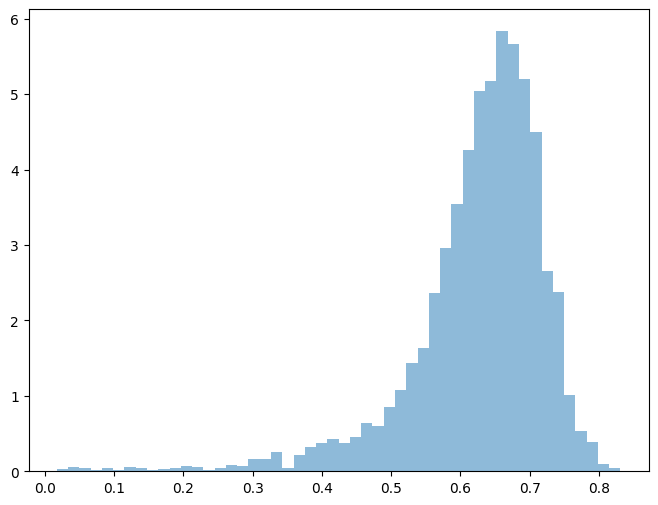

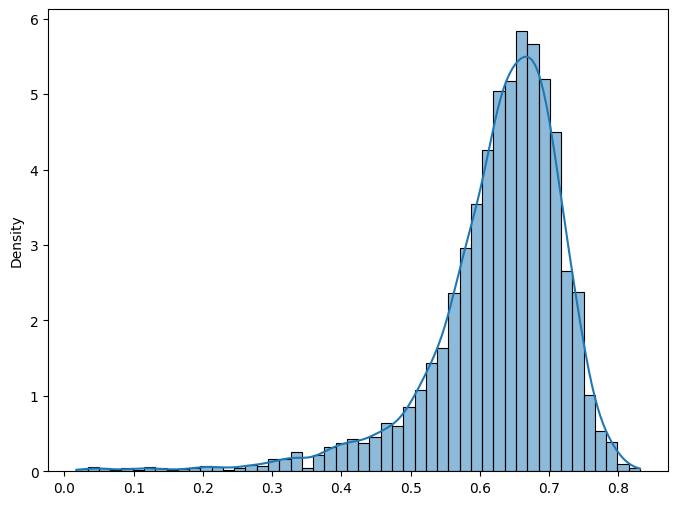

Errors distribution for nnPU


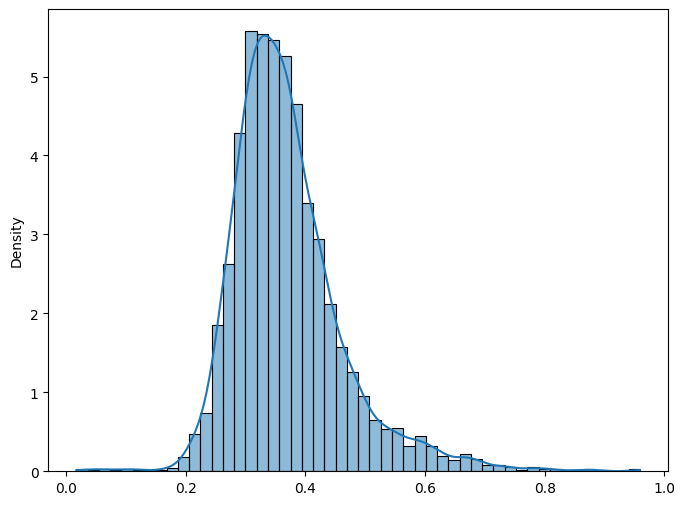

Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 1.0000 - pos_fraction: 0.0000e+00Posterior outputs distribution for nnPU with threshold=1.00


c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


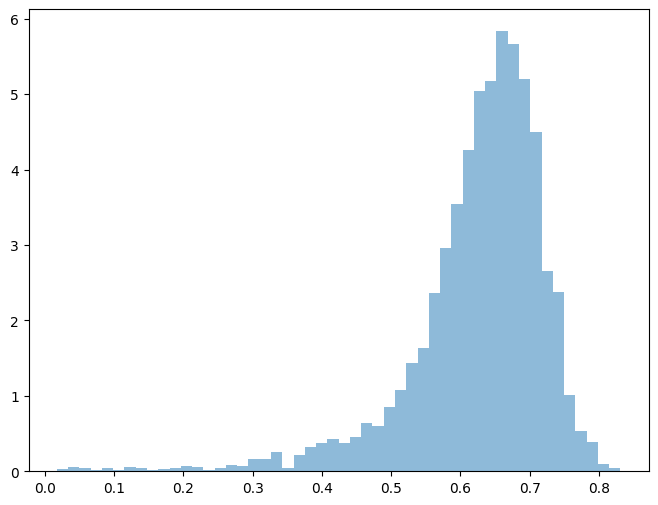

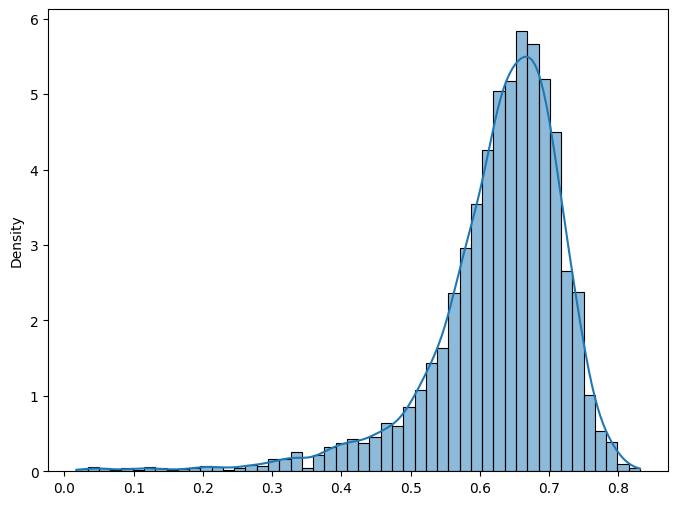

Errors distribution for nnPU


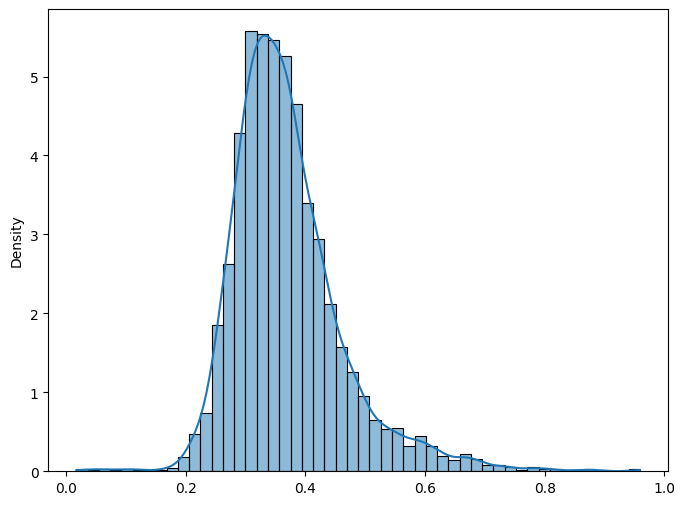

Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 96.7000 - pos_fraction: 0.9638Posterior outputs distribution for nnPU with threshold=0.41


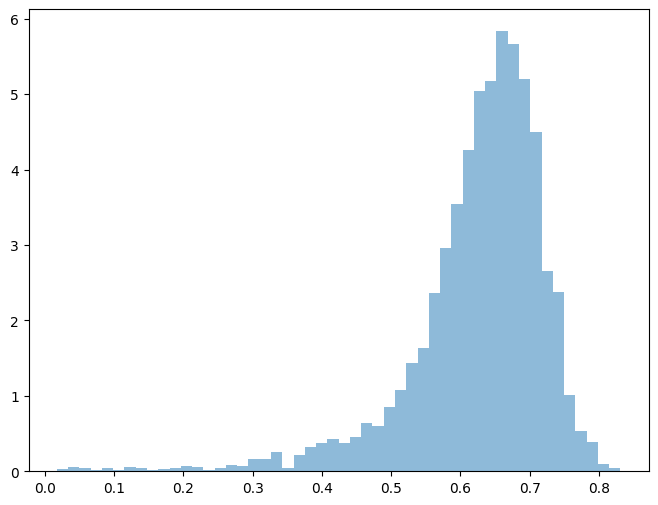

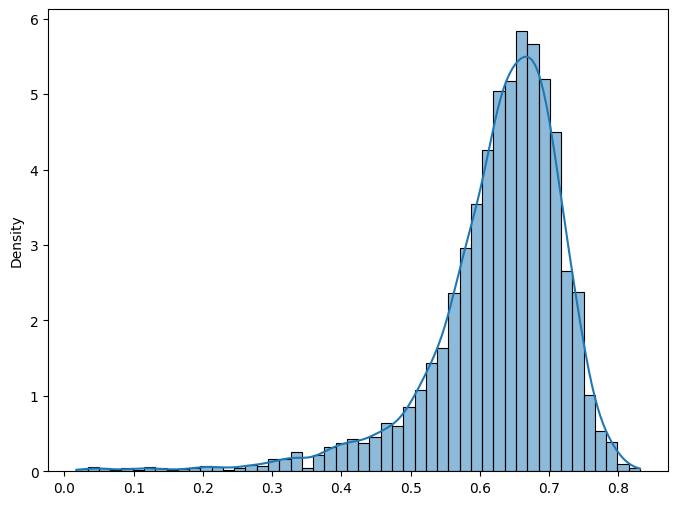

Errors distribution for nnPU


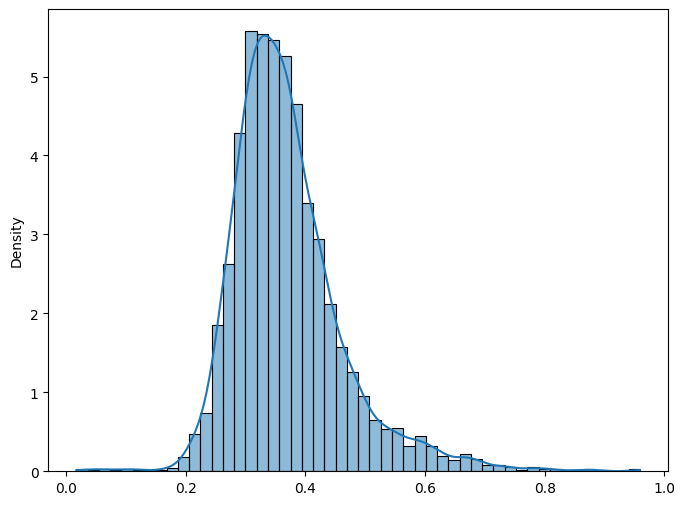

Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 55.8600 - pos_fraction: 0.5634Posterior outputs distribution for DRPU with threshold=0.08


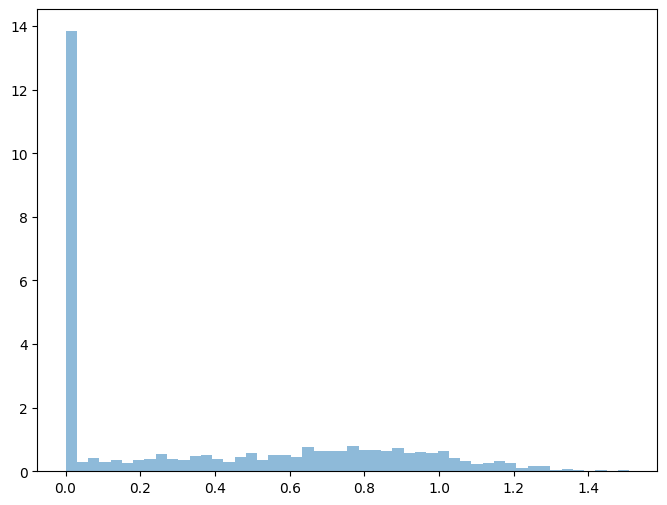

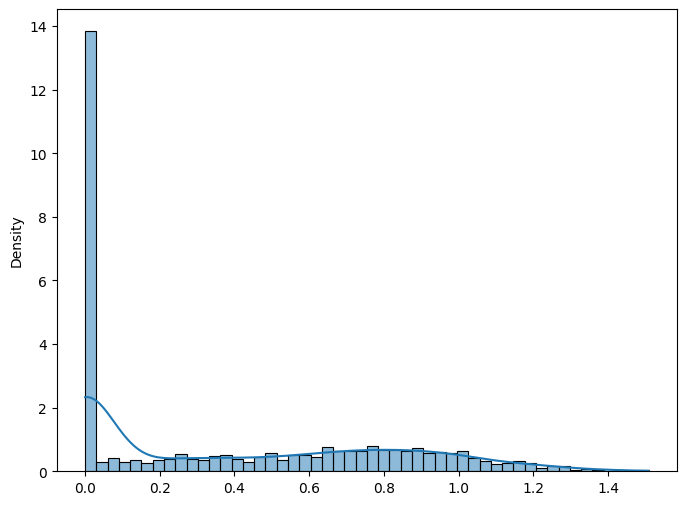

Errors distribution for DRPU


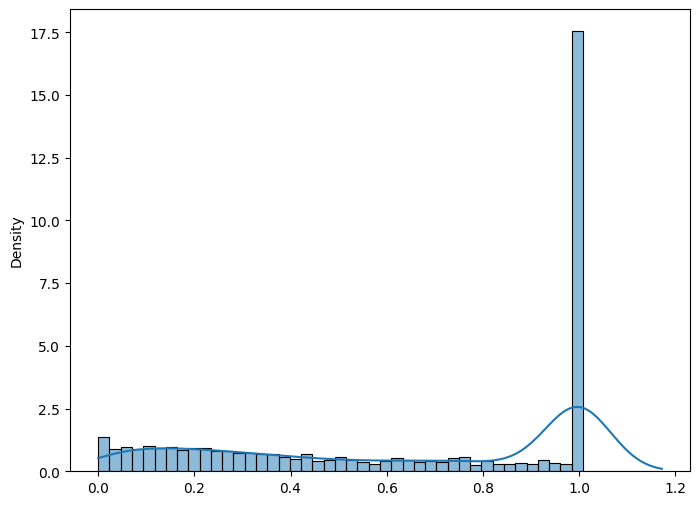

Epoch: 1/1
 1/41 [........] - ETA: 5s - test_loss: 0.1736 - accuracy: 10.1600 - pos_fraction: 0.0940Posterior outputs distribution for DRPU with threshold=1.00


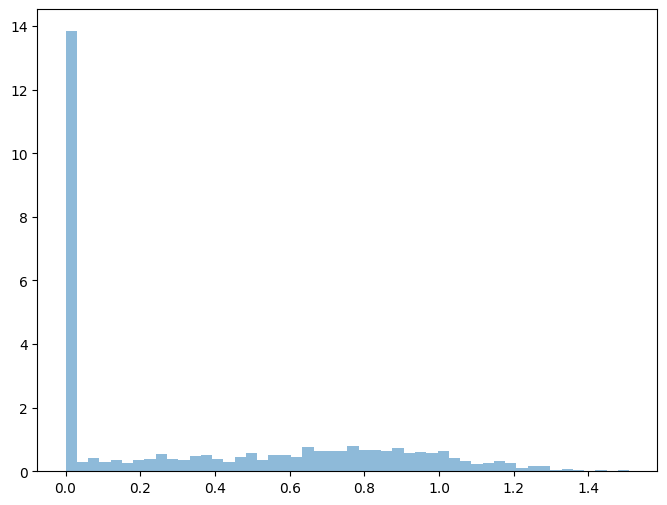

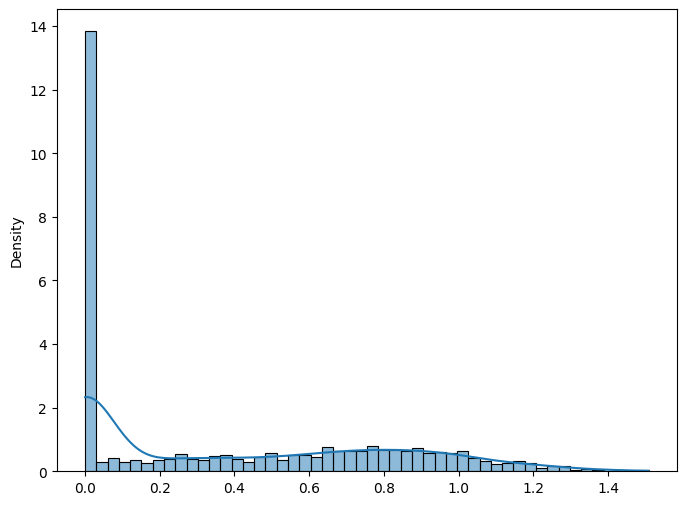

Errors distribution for DRPU


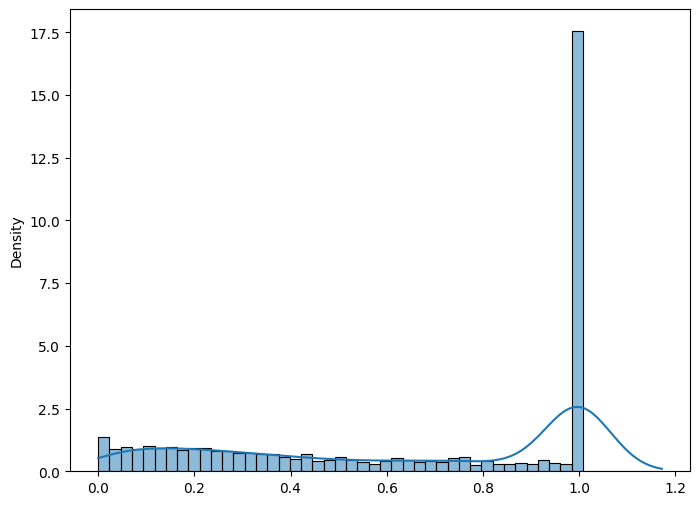

Epoch: 1/1
 1/41 [........] - ETA: 5s - test_loss: 0.5255 - accuracy: 84.4400 - pos_fraction: 0.8364Posterior outputs distribution for nnPU-KM2 with threshold=0.50


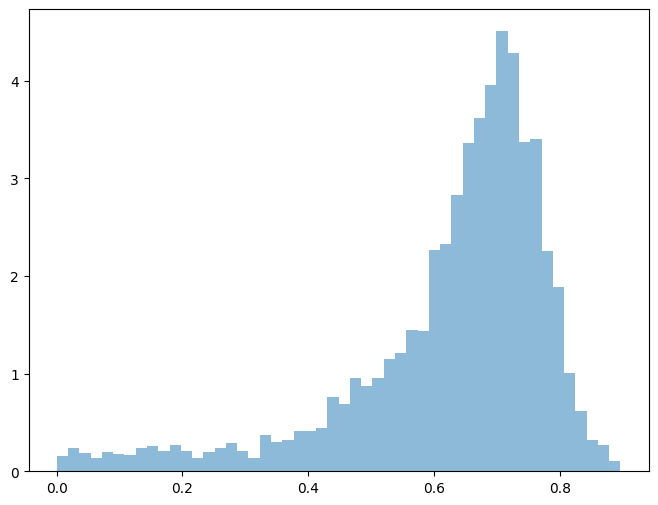

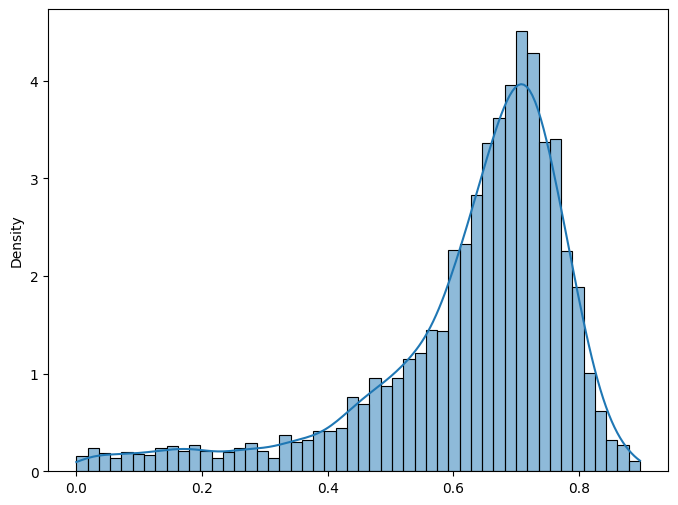

Errors distribution for nnPU-KM2


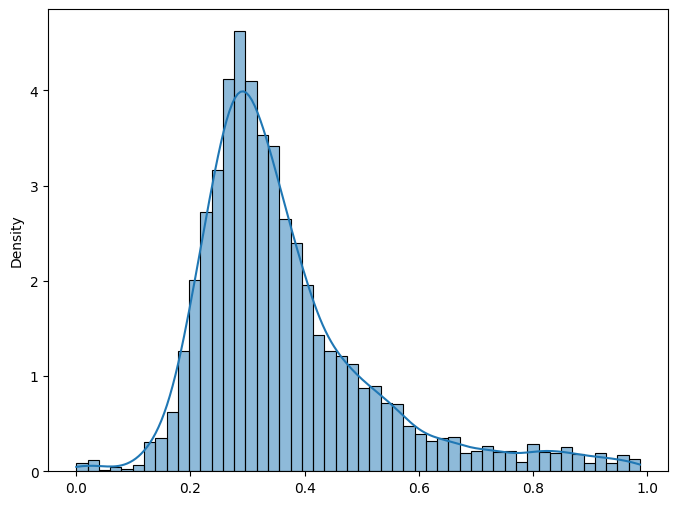

Epoch: 1/1
 1/41 [........] - ETA: 5s - test_loss: 0.5562 - accuracy: 99.0000 - pos_fraction: 1.0000nnPU Threshold: 0.00, Accuracy: 0.9900
Epoch: 1/1
 1/41 [........] - ETA: 6s - test_loss: 0.5562 - accuracy: 99.0000 - pos_fraction: 1.0000nnPU Threshold: 0.01, Accuracy: 0.9900
Epoch: 1/1
 1/41 [........] - ETA: 6s - test_loss: 0.5562 - accuracy: 99.0200 - pos_fraction: 0.9998nnPU Threshold: 0.02, Accuracy: 0.9902
Epoch: 1/1
 1/41 [........] - ETA: 6s - test_loss: 0.5562 - accuracy: 99.0400 - pos_fraction: 0.9996nnPU Threshold: 0.03, Accuracy: 0.9904
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 99.0600 - pos_fraction: 0.9994nnPU Threshold: 0.04, Accuracy: 0.9906
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.5562 - accuracy: 99.0200 - pos_fraction: 0.9986nnPU Threshold: 0.05, Accuracy: 0.9902
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.5562 - accuracy: 99.0600 - pos_fraction: 0.9982nnPU Threshold: 0.06, Accuracy: 0.9906
Epoch: 1/1
 1/41 [........]

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 0.86, Accuracy: 0.0100
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 0.87, Accuracy: 0.0100
Epoch: 1/1


c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 0.88, Accuracy: 0.0100
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 0.89, Accuracy: 0.0100
Epoch: 1/1


...

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 4s - test_loss: 0.5562 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 1.00, Accuracy: 0.0100
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 99.0000 - pos_fraction: 1.0000DRPU Threshold: 0.00, Accuracy: 0.9900
Epoch: 1/1


c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 58.3200 - pos_fraction: 0.5884DRPU Threshold: 0.01, Accuracy: 0.5832
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 58.0400 - pos_fraction: 0.5856DRPU Threshold: 0.02, Accuracy: 0.5804
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 57.7600 - pos_fraction: 0.5828DRPU Threshold: 0.03, Accuracy: 0.5776
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 57.3800 - pos_fraction: 0.5790DRPU Threshold: 0.04, Accuracy: 0.5738
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 57.0200 - pos_fraction: 0.5754DRPU Threshold: 0.05, Accuracy: 0.5702
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 56.8400 - pos_fraction: 0.5732DRPU Threshold: 0.06, Accuracy: 0.5684
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.1736 - accuracy: 56.5400 - pos_fraction: 0.5702DRPU Threshold: 0.07, Accuracy: 0.5654
Epoch: 1/1
 1/41 [........] - ETA: 4s 

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


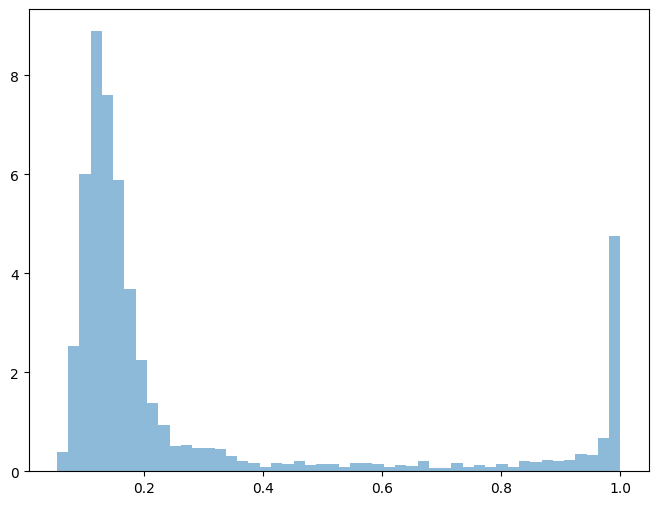

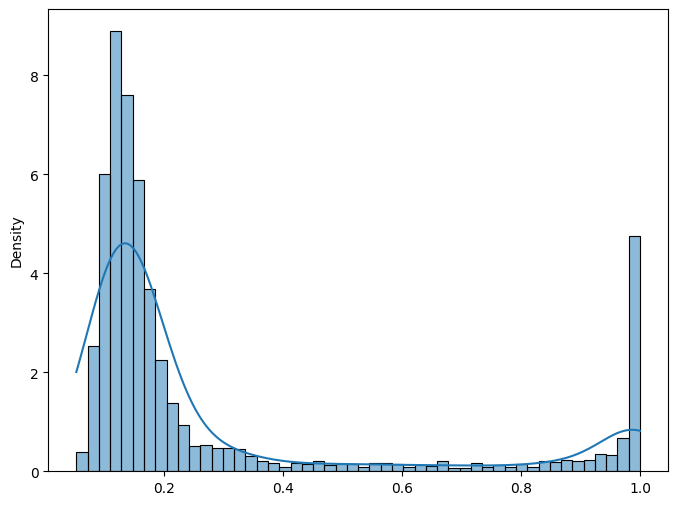

Errors distribution for Mixed-nnPU


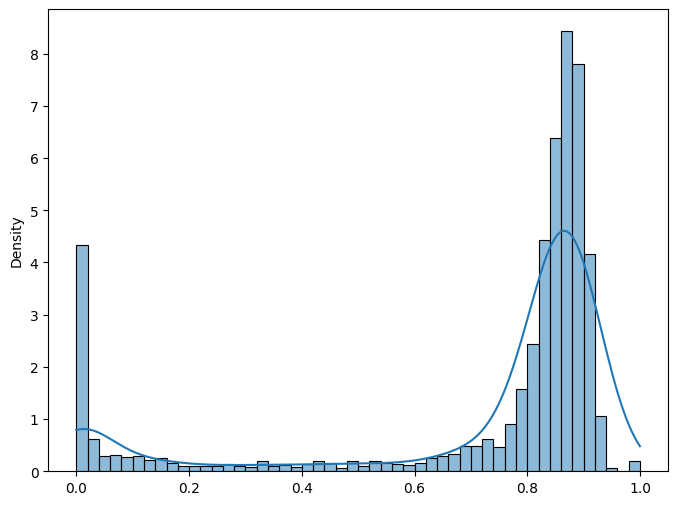

0.08521587301587302
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.0319 - accuracy: 1.0000 - pos_fraction: 0.0000e+00Posterior outputs distribution for Mixed-DRPU with threshold=0.50


c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


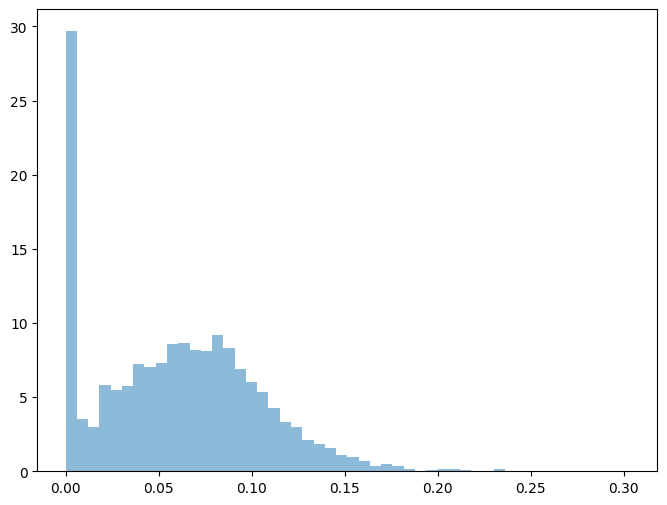

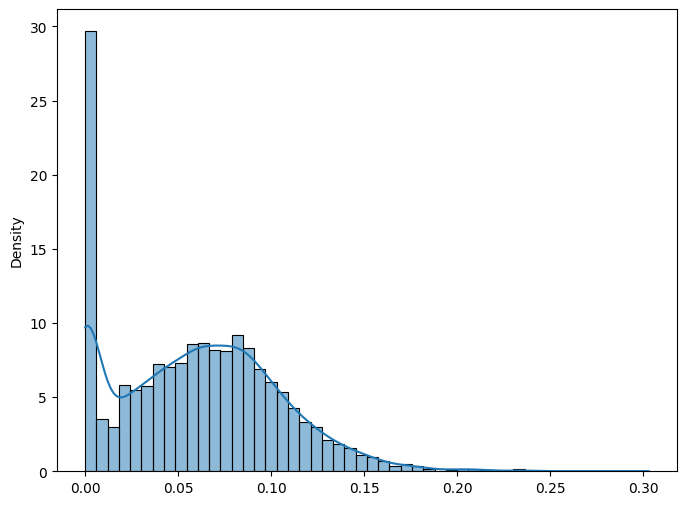

Errors distribution for Mixed-DRPU


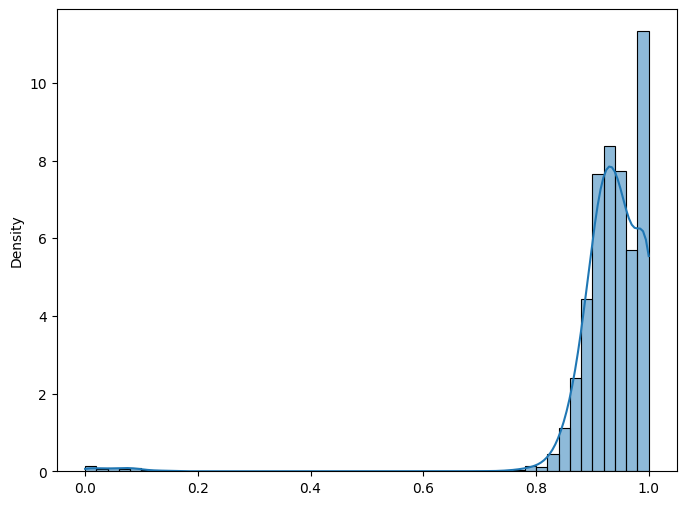

Metrics saved to output\Gauss/5000/0.8/0.9/0.99\0.5\0\metrics.json
[Experiment] PyTorch version: 2.0.1+cpu
[Experiment] CUDA available: False
[Experiment] Using device: cpu
Epoch: 1/50
[nnPU] Model device: cpu
[nnPU] Data tensor device: cpu
[nnPU] Label tensor device: cpu
11/11 [========] - 0s 41ms/step - loss: 0.5139 - acc: 0.4432 - test_loss: 0.4613 - test_accuracy: 82.4400 - pos_fraction: 0.8300
Epoch: 2/50
11/11 [========] - 0s 27ms/step - loss: 0.5041 - acc: 0.4710 - test_loss: 0.4626 - test_accuracy: 68.4400 - pos_fraction: 0.6856
Epoch: 3/50
11/11 [========] - 0s 33ms/step - loss: 0.4938 - acc: 0.5037 - test_loss: 0.4572 - test_accuracy: 57.5200 - pos_fraction: 0.5728
Epoch: 4/50
11/11 [========] - 0s 33ms/step - loss: 0.4847 - acc: 0.5388 - test_loss: 0.4452 - test_accuracy: 55.7800 - pos_fraction: 0.5538
Epoch: 5/50
11/11 [========] - 0s 29ms/step - loss: 0.4747 - acc: 0.5616 - test_loss: 0.4478 - test_accuracy: 56.5400 - pos_fraction: 0.5602
Epoch: 6/50
11/11 [========] - 0s 

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 6s - test_loss: 0.5445 - accuracy: 99.0000 - pos_fraction: 1.0000nnPU Threshold: 0.00, Accuracy: 0.9900
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5445 - accuracy: 99.0000 - pos_fraction: 1.0000nnPU Threshold: 0.01, Accuracy: 0.9900
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5445 - accuracy: 99.0000 - pos_fraction: 1.0000nnPU Threshold: 0.02, Accuracy: 0.9900
Epoch: 1/1
 1/41 [........] - ETA: 5s - test_loss: 0.5445 - accuracy: 99.0200 - pos_fraction: 0.9998nnPU Threshold: 0.03, Accuracy: 0.9902
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5445 - accuracy: 99.0400 - pos_fraction: 0.9996nnPU Threshold: 0.04, Accuracy: 0.9904
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.5445 - accuracy: 99.0400 - pos_fraction: 0.9996nnPU Threshold: 0.05, Accuracy: 0.9904
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5445 - accuracy: 99.0600 - pos_fraction: 0.9994nnPU Threshold: 0.06, Accuracy: 0.9906
Epoch: 1/1
 1/41 [........] - ETA: 4s 

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 4s - test_loss: 0.5445 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 0.94, Accuracy: 0.0100
Epoch: 1/1
 1/41 [........] - ETA: 4s - test_loss: 0.5445 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 0.95, Accuracy: 0.0100
Epoch: 1/1


...

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 1/41 [........] - ETA: 4s - test_loss: 0.4935 - accuracy: 1.0000 - pos_fraction: 0.0000e+00nnPU Threshold: 1.00, Accuracy: 0.0100
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 99.0000 - pos_fraction: 1.0000DRPU Threshold: 0.00, Accuracy: 0.9900
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 73.5600 - pos_fraction: 0.7316

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


DRPU Threshold: 0.01, Accuracy: 0.7356
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 73.2200 - pos_fraction: 0.7282DRPU Threshold: 0.02, Accuracy: 0.7322
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 73.1600 - pos_fraction: 0.7276DRPU Threshold: 0.03, Accuracy: 0.7316
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 72.9800 - pos_fraction: 0.7258DRPU Threshold: 0.04, Accuracy: 0.7298
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 72.6800 - pos_fraction: 0.7228DRPU Threshold: 0.05, Accuracy: 0.7268
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 72.3000 - pos_fraction: 0.7186DRPU Threshold: 0.06, Accuracy: 0.7230
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 72.1000 - pos_fraction: 0.7162DRPU Threshold: 0.07, Accuracy: 0.7210
Epoch: 1/1
 1/41 [........] - ETA: 3s - test_loss: 0.1954 - accuracy: 71.8200 - pos_fraction: 0.7134DRPU Threshold: 0.08, Accur

c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\izate\miniforge3\envs\puls\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [1]:
# gauss - test
from PULS.models import LabelShiftConfig
from PULS.dataset import Gauss_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_config import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss

K = 10
n = 5000
label_frequency = 0.5
dataset_name = "Gauss"
train_pi = 0.9
test_pi = 0.99

for exp_number in range(K):

    label_shift_config = LabelShiftConfig(train_prior=train_pi, train_n_samples=n, test_prior=test_pi, test_n_samples=n)

    dataset_config = DatasetConfig(
        f"{dataset_name}/{label_shift_config.train_n_samples or 'all'}/0.8/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
        DatasetClass=Gauss_PULS,
        PULabelerClass=SCAR_CC_Labeler,
    )
    
    gauss_experiment_config = ExperimentConfig(
        PULoss=nnPUccLoss,  # sigmoid loss
        dataset_config=dataset_config,
        label_frequency=label_frequency,
        exp_number=exp_number,
        force_cpu=True, 
    )

    experiment = PULSExperiment(experiment_config=gauss_experiment_config, label_shift_config=label_shift_config)
    # experiment.train_nnpu_km2_and_test()
    experiment.train_all()
    experiment.test_shifted(plot_model_outputs=exp_number==0)

    # print(experiment.metrics)
    # print(experiment.test_pis)

## Experiment 2 - MNIST

In [ ]:
# mnist
# train data
# 60000 observations (30000 positive, prior - 0.5)
# test data
# 10000 observations (5000 positive, prior - 0.5)

from PULS.models import LabelShiftConfig
from PULS.dataset import MNIST_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_configs import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss

K = 10
label_frequency = 0.5
pi_grid = [0.2, 0.4, 0.6, 0.8]

for test_pi in pi_grid:
    for exp_number in range(K):
        label_shift_config = LabelShiftConfig(train_prior=0.5, train_n_samples=5000, test_prior=test_pi, test_n_samples=5000)

        dataset_config = DatasetConfig(
            f"MNIST/{label_shift_config.train_n_samples or 'all'}/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
            DatasetClass=MNIST_PULS,
            PULabelerClass=SCAR_CC_Labeler,
        )
        experiment_config = ExperimentConfig(
            PULoss=nnPUccLoss,
            dataset_config=dataset_config,
            label_frequency=label_frequency,
            exp_number=exp_number,
            force_cpu=True,
        )

        experiment = PULSExperiment(experiment_config=experiment_config, label_shift_config=label_shift_config)
        experiment.train_all()
        experiment.test_shifted(plot_model_outputs=exp_number==0)

        print(experiment.metrics)
        print(experiment.test_pis)

## Experiment 3 - FashionMNIST

In [ ]:
# fashion mnist
# train data
# 60000 observations (30000 positive, prior - 0.5)
# test data
# 10000 observations (5000 positive, prior - 0.5)

from PULS.models import LabelShiftConfig
from PULS.dataset import FashionMNIST_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_config import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss

K = 10
label_frequency = 0.5
pi_grid = [0.2, 0.4, 0.6, 0.8]

for test_pi in pi_grid:
    for exp_number in range(K):
        label_shift_config = LabelShiftConfig(train_prior=0.5, train_n_samples=5000, test_prior=test_pi, test_n_samples=5000)

        dataset_config = DatasetConfig(
            f"FashionMNIST/{label_shift_config.train_n_samples or 'all'}/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
            DatasetClass=FashionMNIST_PULS,
            PULabelerClass=SCAR_CC_Labeler,
        )
        experiment_config = ExperimentConfig(
            PULoss=nnPUccLoss,
            dataset_config=dataset_config,
            label_frequency=label_frequency,
            exp_number=exp_number,
            force_cpu=True,
        )

        experiment = PULSExperiment(experiment_config=experiment_config, label_shift_config=label_shift_config)
        experiment.train_all()
        experiment.test_shifted(plot_model_outputs=exp_number==0)

        print(experiment.metrics)
        print(experiment.test_pis)

## Experiment 4 - ChestXRay

In [ ]:
# ChestXRay
# train data
# 4077 observations (2973 positive, prior - 0.729)
# test data
# 582 observations (411 positive, prior - 0.706)

from PULS.models import LabelShiftConfig
from PULS.dataset import ChestXRay_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_config import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss

K = 10
label_frequency = 0.5
pi_grid = [0.2, 0.4, 0.6, 0.8]

for test_pi in pi_grid:
    for exp_number in range(K):
        label_shift_config = LabelShiftConfig(train_prior=0.5, train_n_samples=5000, test_prior=test_pi, test_n_samples=5000)

        dataset_config = DatasetConfig(
            f"ChestXRay/{label_shift_config.train_n_samples or 'all'}/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
            DatasetClass=ChestXRay_PULS,
            PULabelerClass=SCAR_CC_Labeler,
        )
        experiment_config = ExperimentConfig(
            PULoss=nnPUccLoss,
            dataset_config=dataset_config,
            label_frequency=label_frequency,
            exp_number=exp_number,
            force_cpu=True,
        )

        experiment = PULSExperiment(experiment_config=experiment_config, label_shift_config=label_shift_config)
        experiment.train_all()
        experiment.test_shifted(plot_model_outputs=exp_number==0)

        print(experiment.metrics)
        print(experiment.test_pis)

## Experiment 5 - CIFAR10

In [ ]:
# CIFAR-10
# train data
# 50,000 observations (30,000 positive, prior - 0.6)
# test data
# 10,000 observations (5,400 positive, prior - 0.6)

from PULS.models import LabelShiftConfig
from PULS.dataset import CIFAR_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_config import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss

K = 10
label_frequency = 0.5
pi_grid = [0.2, 0.4, 0.6, 0.8]

for test_pi in pi_grid:
    for exp_number in range(K):
        label_shift_config = LabelShiftConfig(train_prior=0.5, train_n_samples=5000, test_prior=test_pi, test_n_samples=5000)

        dataset_config = DatasetConfig(
            f"CIFAR10/{label_shift_config.train_n_samples or 'all'}/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
            DatasetClass=CIFAR_PULS,
            PULabelerClass=SCAR_CC_Labeler,
        )
        experiment_config = ExperimentConfig(
            PULoss=nnPUccLoss,
            dataset_config=dataset_config,
            label_frequency=label_frequency,
            exp_number=exp_number,
            force_cpu=True,
        )

        experiment = PULSExperiment(experiment_config=experiment_config, label_shift_config=label_shift_config)
        experiment.train_all()
        experiment.test_shifted(plot_model_outputs=exp_number==0)

        print(experiment.metrics)
        print(experiment.test_pis)

## Experiment 6 - Electricity

In [ ]:
# Electricity
# train data
# 30,779 observations (15,372 positive, prior - 0.5)
# test data
# 7,695 observations (3,865 positive, prior - 0.5)

from PULS.models import LabelShiftConfig
from PULS.dataset import TBElectricity_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_config import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss

K = 10
label_frequency = 0.5
pi_grid = [0.2, 0.4, 0.6, 0.8]

for test_pi in pi_grid:
    for exp_number in range(K):
        label_shift_config = LabelShiftConfig(train_prior=0.5, train_n_samples=5000, test_prior=test_pi, test_n_samples=5000)

        dataset_config = DatasetConfig(
            f"Electricity/{label_shift_config.train_n_samples or 'all'}/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
            DatasetClass=TBElectricity_PULS,
            PULabelerClass=SCAR_CC_Labeler,
        )
        experiment_config = ExperimentConfig(
            PULoss=nnPUccLoss,
            dataset_config=dataset_config,
            label_frequency=label_frequency,
            exp_number=exp_number,
            force_cpu=True,
        )

        experiment = PULSExperiment(experiment_config=experiment_config, label_shift_config=label_shift_config)
        experiment.train_all()
        experiment.test_shifted(plot_model_outputs=exp_number==0)

        print(experiment.metrics)
        print(experiment.test_pis)

## Experiment 7 - SMSSpam

In [ ]:
# SMSSpam
# train data
# 4,459 observations (602 positive, prior - 0.13)
# test data
# 1,115 observations (145 positive, prior - 0.13)

from PULS.models import LabelShiftConfig
from PULS.dataset import SMSSpam_PULS
from PULS.experiment import PULSExperiment

from nnPU.dataset import SCAR_CC_Labeler
from nnPU.dataset_config import DatasetConfig
from nnPU.experiment_config import ExperimentConfig
from nnPU.loss import nnPUccLoss

K = 10
label_frequency = 0.5
pi_grid = [0.2, 0.4, 0.6, 0.8]

for test_pi in pi_grid:
    for exp_number in range(K):
        label_shift_config = LabelShiftConfig(train_prior=0.5, train_n_samples=5000, test_prior=test_pi, test_n_samples=5000)

        dataset_config = DatasetConfig(
            f"SMSSpam/{label_shift_config.train_n_samples or 'all'}/{label_shift_config.train_prior or 'all'}/{label_shift_config.test_prior or 'all'}",
            DatasetClass=SMSSpam_PULS,
            PULabelerClass=SCAR_CC_Labeler,
        )
        experiment_config = ExperimentConfig(
            PULoss=nnPUccLoss,
            dataset_config=dataset_config,
            label_frequency=label_frequency,
            exp_number=exp_number,
            force_cpu=True,
        )

        experiment = PULSExperiment(experiment_config=experiment_config, label_shift_config=label_shift_config)
        experiment.train_all()
        experiment.test_shifted(plot_model_outputs=exp_number==0)

        print(experiment.metrics)
        print(experiment.test_pis)